# Attack/defense bivariate-Poisson models for World Cup scores

**Deep dive.** This notebook builds a *factorial state-space model* (fSSM) of international football that predicts **scorelines** for the 2026 FIFA World Cup, following the [`cuthberto-carlos`](https://github.com/state-space-models/cuthberto-carlos) formulation. It extends the win/draw/loss skill model with a richer **attack/defense** state and a **bivariate Poisson** goal likelihood, estimates **all** hyperparameters by gradient ascent on the differentiable particle-filter marginal likelihood, evaluates the fitted model **online**, and compares the gradient-MLE parameters against a full **NUTS** posterior and the **Duffield et al.** values.

Each team carries a *two-dimensional* latent skill — attacking and defensive strength — that evolves as Brownian motion, and a match's scoreline is modelled with the bivariate Poisson distribution of [Karlis & Ntzoufras (2003)](https://doi.org/10.1111/1467-9884.00366) (Duffield et al. 2024, §4.6):

$$
\begin{aligned}
p(x^i_0) &= \mathrm N(\mu_0, \Sigma_0), &
p(x^i_k \mid x^i_{k-1}) &= \mathrm N\!\big(x^i_{k-1}, \tau^2 (t_k - t_{k-1})\big), \\[2pt]
p(y_k \mid x^i_k, x^j_k) &= \mathrm{BivariatePoisson}(y_k \mid \lambda_1, \lambda_2, \lambda_3),
\end{aligned}
$$

with $x^i = (x^{\mathrm{att},i}, x^{\mathrm{def},i})$, scoreline $y_k = (y^i_k, y^j_k)$, and rates

$$
\lambda_1 = e^{\alpha + x^{\mathrm{att},i} - x^{\mathrm{def},j}},\quad
\lambda_2 = e^{\alpha + x^{\mathrm{att},j} - x^{\mathrm{def},i}},\quad
\lambda_3 = e^{\beta}.
$$

The static hyperparameters are $\theta = \{\mu_0 \in \mathbb R^2,\ \Sigma_0 \in \mathbb R^{2\times2},\ \tau \in \mathbb R^2_{>0},\ \alpha,\ \beta\}$. We reuse the same `FactorialDynamicalModel` + `dsx.sample` machinery as the scalar model — only the per-factor state dimension (`2`) and the observation model change.


In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import optax
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, init_to_value

import dynestyx as dsx
from dynestyx import (
    FactorialDynamicalModel,
    RandomWalkEvolution,
    BivariatePoissonScoreObservation,
    Filter,
    Smoother,
    FactorialEKFConfig,
    FactorialEKFSmootherConfig,
    FactorialPFConfig,
    factorial_score_probabilities,
)
from dynestyx.inference.integrations.cuthbert.factorial_filter import (
    compute_factorial_filter,
)

jax.config.update("jax_enable_x64", True)

## 1. Data: scorelines and the 2026 World Cup fixtures

We download Mart Jürisoo's open [`international_results`](https://github.com/martj42/international_results) dataset at runtime; it already contains the **2026 World Cup fixtures** as future rows with missing scores. We focus on the 48 World Cup teams and their head-to-head matches since 2015; the observations are the **scorelines** `(home_goals, away_goals)`.


In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df = pd.read_csv(URL, parse_dates=["date"])

future = df[
    df["home_score"].isna()
    & (df["tournament"] == "FIFA World Cup")
    & (df["date"] >= "2026-06-01")
].sort_values("date")
wc_teams = sorted(set(future["home_team"]) | set(future["away_team"]))
team_idx = {t: i for i, t in enumerate(wc_teams)}
F = len(wc_teams)

played = df.dropna(subset=["home_score", "away_score"]).copy()
played = played[
    (played["date"] >= "2015-01-01")
    & played["home_team"].isin(team_idx)
    & played["away_team"].isin(team_idx)
].sort_values("date").reset_index(drop=True)

t0_date = played["date"].min()
K = len(played)
days = (played["date"] - t0_date).dt.days.to_numpy().astype(float)
# Time in years, plus a tiny ramp so identical dates are strictly increasing.
obs_times = jnp.asarray(days / 365.25 + np.arange(K) * 1e-6)
obs_factor_indices = jnp.asarray(
    np.stack(
        [
            played["home_team"].map(team_idx).to_numpy(),
            played["away_team"].map(team_idx).to_numpy(),
        ],
        axis=1,
    ).astype(np.int32)
)
obs_values = jnp.asarray(
    np.stack(
        [played["home_score"].to_numpy(), played["away_score"].to_numpy()], axis=1
    ).astype(np.int32)
)
MAX_GOALS = int(max(played["home_score"].max(), played["away_score"].max())) + 8

print(f"{F} teams, {K} historical scorelines, {len(future)} World Cup fixtures to predict")

48 teams, 1314 historical scorelines, 72 World Cup fixtures to predict


## 2. The bivariate-Poisson factorial model

The per-factor state is 2-D `(attack, defense)`. We parameterise the hyperparameters in an *unconstrained* space for gradient-based optimisation: $\Sigma_0 = LL^\top$ via a lower-Cholesky factor $L$ (positive diagonal through $\exp$), and $\tau = \exp(\cdot)$. `make_model` turns a parameter pytree into a `FactorialDynamicalModel`.


In [3]:
D = 2  # (attack, defense) per team


def natural_params(p):
    """Map the unconstrained parameter pytree to natural parameters."""
    chol_diag = jnp.exp(p["log_chol_diag"])  # positive diagonal of L  (2,)
    scale_tril = jnp.array(
        [[chol_diag[0], 0.0], [p["chol_offdiag"][0], chol_diag[1]]]
    )  # Sigma_0 = L L^T
    tau = jnp.exp(p["log_tau"])  # (2,) positive drift rates
    return p["mu0"], scale_tril, tau, p["alpha"], p["beta"]


def make_model(p):
    mu0, scale_tril, tau, alpha, beta = natural_params(p)
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(mu0, scale_tril=scale_tril),
        state_evolution=RandomWalkEvolution(tau=tau, factor_state_dim=D),
        observation_model=BivariatePoissonScoreObservation(
            alpha=alpha, beta=beta, factor_state_dim=D, max_goals=MAX_GOALS
        ),
        num_factors=F,
        num_local_factors=2,
        t0=0.0,
    )


init_params = {
    "mu0": jnp.zeros(2),
    "log_chol_diag": jnp.log(jnp.array([0.5, 0.5])),
    "chol_offdiag": jnp.zeros(1),
    "log_tau": jnp.log(jnp.array([0.4, 0.4])),
    "alpha": jnp.array(0.25),
    "beta": jnp.array(-1.5),
}

## 3. Estimating all hyperparameters: PF marginal likelihood + gradient ascent

We fit $\theta$ by maximising the marginal likelihood $\log p(y_{1:K} \mid \theta)$. The factorial *EKF* evidence is a Laplace approximation that is not differentiable through the linearised categorical update, but the factorial **particle filter** gives a differentiable estimate (stop-gradient resampling, Ścibior & Wood 2021). So we minimise the negative PF marginal log-likelihood with Adam, using a **fixed PRNG key** (common random numbers) so the objective is a deterministic, smooth function of $\theta$.

A note on identifiability: a match constrains only *contrasts* (attack minus the opponent's defense), so $\mu_0$ and $\alpha$ share a flat direction — the optimiser simply settles on that ridge, which does not affect predictions.


In [4]:
N_OPT = 300  # particles for the optimisation objective
N_STEPS = 150
OPT_KEY = jax.random.PRNGKey(0)  # common random numbers -> deterministic objective


def neg_loglik_per_match(p):
    loglik, *_ = compute_factorial_filter(
        make_model(p),
        FactorialPFConfig(n_particles=N_OPT),
        OPT_KEY,
        obs_times=obs_times,
        obs_values=obs_values,
        obs_factor_indices=obs_factor_indices,
    )
    return -loglik / K


value_and_grad = jax.jit(jax.value_and_grad(neg_loglik_per_match))

params = init_params
optimizer = optax.adam(0.05)
opt_state = optimizer.init(params)
losses = []
for step in range(N_STEPS):
    loss, grads = value_and_grad(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    losses.append(float(loss))
    if step % 25 == 0 or step == N_STEPS - 1:
        print(f"step {step:3d}   neg loglik / match = {float(loss):.4f}")
opt_params = params

step   0   neg loglik / match = 2.9929


step  25   neg loglik / match = 2.9066


step  50   neg loglik / match = 2.8900


step  75   neg loglik / match = 2.8889


step 100   neg loglik / match = 2.8901


step 125   neg loglik / match = 2.8886


step 149   neg loglik / match = 2.8876


Learned (gradient-MLE) hyperparameters
  alpha = +0.214   beta = -2.901  (lambda3 = 0.055)
  tau   = [0.049 0.064]   (attack, defense drift)
  Sigma0 diag = [0.099 0.052]


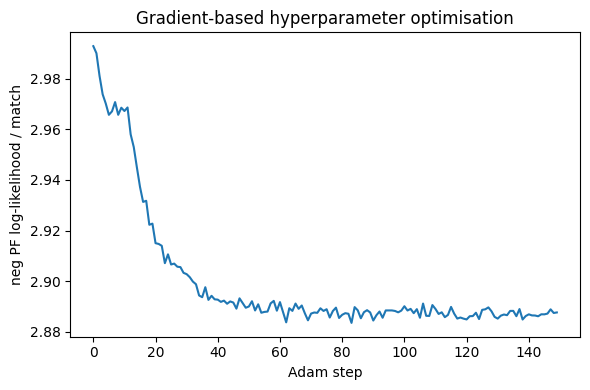

In [5]:
mu0, scale_tril, tau, alpha, beta = natural_params(opt_params)
print("Learned (gradient-MLE) hyperparameters")
print(f"  alpha = {float(alpha):+.3f}   beta = {float(beta):+.3f}  (lambda3 = {float(jnp.exp(beta)):.3f})")
print(f"  tau   = {np.round(np.asarray(tau), 3)}   (attack, defense drift)")
print(f"  Sigma0 diag = {np.round(np.diag(np.asarray(scale_tril @ scale_tril.T)), 3)}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(losses)
ax.set_xlabel("Adam step"); ax.set_ylabel("neg PF log-likelihood / match")
ax.set_title("Gradient-based hyperparameter optimisation")
fig.tight_layout(); plt.show()

## 4. Filtering at the learned parameters: attack & defense ratings

We run the fast deterministic **EKF** at $\hat\theta$ to obtain each team's current 2-D skill. Higher attack means more goals scored; higher defense means fewer conceded (it enters opponents' rates as $-x^{\mathrm{def}}$), so we rank by attack + defense.


In [6]:
def world_cup_model(model, predict_times=None, predict_factor_indices=None):
    with Filter(filter_config=FactorialEKFConfig(record_filtered_states_mean=True)):
        dsx.sample(
            "skill",
            model,
            obs_times=obs_times,
            obs_values=obs_values,
            obs_factor_indices=obs_factor_indices,
            predict_times=predict_times,
            predict_factor_indices=predict_factor_indices,
        )


fitted_model = make_model(opt_params)
trace = Predictive(lambda: world_cup_model(fitted_model), num_samples=1)(
    jax.random.PRNGKey(0)
)
skills = np.asarray(trace["skill_filtered_states_mean"][0])  # (F, 2)
attack, defense = skills[:, 0], skills[:, 1]
overall = attack + defense

order = np.argsort(overall)[::-1]
ranking = pd.DataFrame(
    {
        "team": [wc_teams[i] for i in order],
        "attack": attack[order],
        "defense": defense[order],
        "overall": overall[order],
    }
)
ranking.index = np.arange(1, F + 1)
ranking.head(15).round(3)

,team,attack,defense,overall
1,Brazil,0.060,0.112,0.172
2,Croatia,0.048,0.096,0.145
3,United States,0.032,0.090,0.121
4,Argentina,0.020,0.095,0.115
5,Belgium,0.047,0.064,0.110
6,South Korea,0.021,0.080,0.101
7,Japan,0.011,0.076,0.087
8,Iran,-0.022,0.080,0.058
9,Uruguay,-0.011,0.067,0.056
10,Portugal,0.005,0.050,0.055


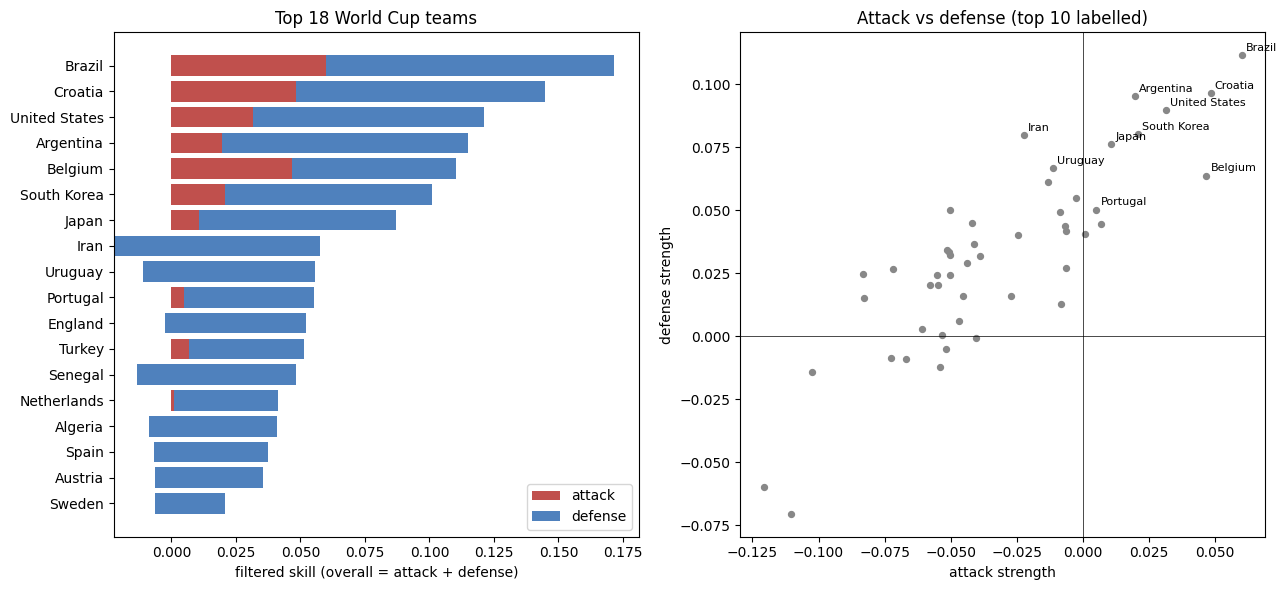

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
top = 18
to = order[:top][::-1]
ax = axes[0]
ax.barh([wc_teams[i] for i in to], attack[to], color="#c0504d", label="attack")
ax.barh([wc_teams[i] for i in to], defense[to], left=attack[to], color="#4f81bd", label="defense")
ax.set_xlabel("filtered skill (overall = attack + defense)")
ax.set_title(f"Top {top} World Cup teams"); ax.legend(loc="lower right")
ax = axes[1]
ax.scatter(attack, defense, s=18, color="#888")
for i in order[:10]:
    ax.annotate(wc_teams[i], (attack[i], defense[i]), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("attack strength"); ax.set_ylabel("defense strength")
ax.set_title("Attack vs defense (top 10 labelled)")
fig.tight_layout(); plt.show()

## 5. Smoothing: attack & defense trajectories

Smoothing conditions each estimate on the full history. We plot the smoothed attack and defense strengths over time for a few teams (solid = attack, dashed = defense).


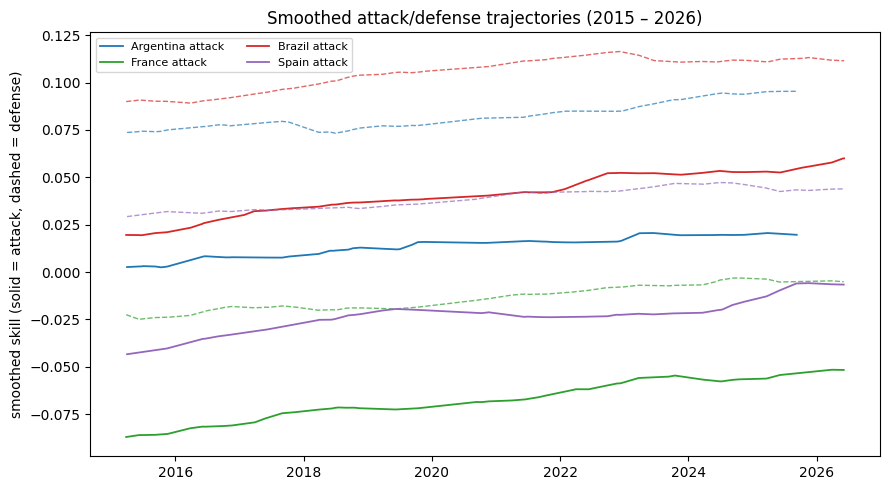

In [8]:
def smoothed_model(model):
    with Smoother(
        smoother_config=FactorialEKFSmootherConfig(record_smoothed_states_mean=True)
    ):
        dsx.sample(
            "skill", model, obs_times=obs_times, obs_values=obs_values,
            obs_factor_indices=obs_factor_indices,
        )


strace = Predictive(lambda: smoothed_model(fitted_model), num_samples=1)(jax.random.PRNGKey(0))
smoothed_local = np.asarray(strace["skill_smoothed_local_states_mean"][0])  # (K, 2, 2)
idx_np = np.asarray(obs_factor_indices)
match_dates = played["date"].to_numpy()


def team_trajectory(team):
    i = team_idx[team]
    dates, att, dfn = [], [], []
    for k in range(K):
        for j in range(2):
            if idx_np[k, j] == i:
                dates.append(match_dates[k]); att.append(smoothed_local[k, j, 0]); dfn.append(smoothed_local[k, j, 1])
    return np.array(dates), np.array(att), np.array(dfn)


fig, ax = plt.subplots(figsize=(9, 5))
for team, color in zip(["Argentina", "France", "Brazil", "Spain"], ["#1f77b4", "#2ca02c", "#d62728", "#9467bd"]):
    if team in team_idx:
        d_, a_, f_ = team_trajectory(team)
        ax.plot(d_, a_, "-", color=color, lw=1.3, label=f"{team} attack")
        ax.plot(d_, f_, "--", color=color, lw=1.0, alpha=0.7)
ax.set_ylabel("smoothed skill (solid = attack, dashed = defense)")
ax.set_title("Smoothed attack/defense trajectories (2015 – 2026)")
ax.legend(ncol=2, fontsize=8); fig.tight_layout(); plt.show()

## 6. Predicting World Cup scorelines

For each fixture we propagate the two teams' filtered skills to the match date and integrate the bivariate-Poisson likelihood over the predictive skill distribution (`factorial_score_probabilities`), giving a **score grid** and **win/draw/loss**.


In [9]:
pred_dates = future["date"].to_numpy()
P = len(future)
predict_times = jnp.asarray(
    (future["date"] - t0_date).dt.days.to_numpy().astype(float) / 365.25 + np.arange(P) * 1e-6
)
predict_factor_indices = jnp.asarray(
    np.stack(
        [future["home_team"].map(team_idx).to_numpy(), future["away_team"].map(team_idx).to_numpy()],
        axis=1,
    ).astype(np.int32)
)

ptrace = Predictive(
    lambda: world_cup_model(fitted_model, predict_times, predict_factor_indices), num_samples=1
)(jax.random.PRNGKey(0))
pred_means = ptrace["skill_predicted_states"][0]
pred_chols = ptrace["skill_predicted_states_chol_cov"][0]

GRID = 6
score_grids, wdl = factorial_score_probabilities(
    fitted_model.observation_model, pred_means, pred_chols,
    key=jax.random.PRNGKey(1), n_samples=4000, max_goals_grid=GRID,
)
score_grids = np.asarray(score_grids); wdl = np.asarray(wdl)
exp_home = (score_grids.sum(2) * np.arange(GRID + 1)).sum(1)
exp_away = (score_grids.sum(1) * np.arange(GRID + 1)).sum(1)

predictions = pd.DataFrame(
    {
        "date": pd.to_datetime(pred_dates).strftime("%Y-%m-%d"),
        "home": future["home_team"].to_numpy(), "away": future["away_team"].to_numpy(),
        "P(home win)": wdl[:, 0], "P(draw)": wdl[:, 1], "P(away win)": wdl[:, 2],
        "exp_home_goals": exp_home, "exp_away_goals": exp_away,
    }
)
predictions.round(2).head(16)

,date,home,away,P(home win),P(draw),P(away win),exp_home_goals,exp_away_goals
0,2026-06-11,Mexico,South Africa,0.37,0.29,0.35,1.21,1.18
1,2026-06-11,South Korea,Czech Republic,0.41,0.28,0.32,1.32,1.13
2,2026-06-12,Canada,Bosnia and Herzegovina,0.38,0.28,0.34,1.25,1.17
3,2026-06-12,United States,Paraguay,0.40,0.28,0.31,1.31,1.12
4,2026-06-13,Qatar,Switzerland,0.35,0.28,0.37,1.23,1.26
5,2026-06-13,Brazil,Morocco,0.41,0.28,0.31,1.30,1.11
6,2026-06-13,Haiti,Scotland,0.36,0.28,0.36,1.22,1.24
7,2026-06-13,Australia,Turkey,0.34,0.28,0.38,1.19,1.26
8,2026-06-14,Sweden,Tunisia,0.37,0.28,0.35,1.24,1.20
9,2026-06-14,Netherlands,Japan,0.35,0.28,0.37,1.20,1.25


### Score-grid heatmaps for selected fixtures

Each grid shows $p(\text{home scores } a,\ \text{away scores } b)$, capped at $6\!-\!6$.


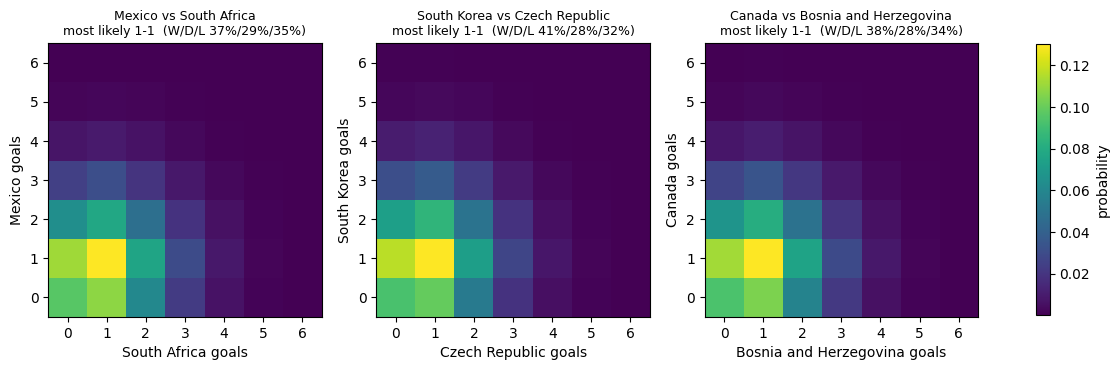

In [10]:
def show_fixture(ax, p):
    g = score_grids[p]
    im = ax.imshow(g, origin="lower", cmap="viridis")
    ax.set_xlabel(f"{future['away_team'].iloc[p]} goals")
    ax.set_ylabel(f"{future['home_team'].iloc[p]} goals")
    ax.set_xticks(range(GRID + 1)); ax.set_yticks(range(GRID + 1))
    best = np.unravel_index(np.argmax(g), g.shape)
    ax.set_title(
        f"{future['home_team'].iloc[p]} vs {future['away_team'].iloc[p]}\n"
        f"most likely {best[0]}-{best[1]}  (W/D/L {wdl[p,0]:.0%}/{wdl[p,1]:.0%}/{wdl[p,2]:.0%})",
        fontsize=9,
    )
    return im


n_show = min(3, P)
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4.4))
axes = np.atleast_1d(axes)
for ax, p in zip(axes, range(n_show)):
    im = show_fixture(ax, p)
fig.colorbar(im, ax=list(axes), shrink=0.8, label="probability")
plt.show()

## 7. Online one-step-ahead performance

How well does a fitted model predict matches *before seeing them*? We run the EKF once over the full history — the filter is **causal** — and exploit the factorial **match-sparsity**: a team's state only changes when it plays, so propagating its last *pre-match* filtered skill forward to the match date gives the genuine one-step-ahead predictive. We package this as `online_eval(model)` and visualise the last 20 matches: expected vs actual goals for/against the home team, with each column shaded green if the outcome was predicted correctly.


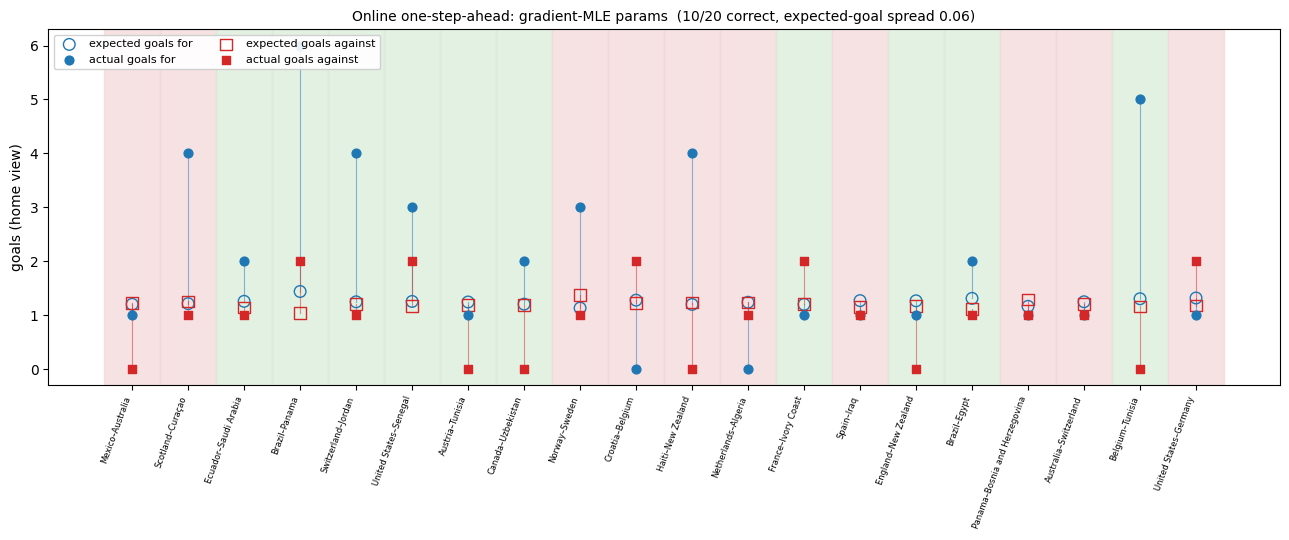

In [11]:
def online_eval(model, n_recent=20):
    """Causal one-step-ahead predictions for the last `n_recent` matches."""
    _, _, loc, _ = compute_factorial_filter(
        model, FactorialEKFConfig(), None,
        obs_times=obs_times, obs_values=obs_values, obs_factor_indices=obs_factor_indices,
    )
    filt_mean = np.asarray(loc.elem.b)   # (K, 2, D)  causal filtered local means
    filt_chol = np.asarray(loc.elem.U)   # (K, 2, D, D)
    idx = np.asarray(obs_factor_indices); tn = np.asarray(obs_times)
    mu0n = np.asarray(model.initial_condition.mean)
    Ln = np.asarray(model.initial_condition.scale_tril); prior_cov = Ln @ Ln.T
    taun = np.asarray(model.state_evolution.tau)

    def last_before(team, k):
        for kk in range(k - 1, -1, -1):
            for j in range(2):
                if idx[kk, j] == team:
                    return tn[kk], filt_mean[kk, j], filt_chol[kk, j] @ filt_chol[kk, j].T
        return 0.0, mu0n, prior_cov

    cut = K - n_recent
    pm, pc = [], []
    for k in range(cut, K):
        bm, bc = [], []
        for team in idx[k]:
            tp, mp, cp = last_before(int(team), k)
            cov = cp + np.diag(taun**2 * (tn[k] - tp))  # random-walk predict
            bm.append(mp); bc.append(np.linalg.cholesky(cov))
        pm.append(np.stack(bm)); pc.append(np.stack(bc))
    pm = jnp.asarray(np.stack(pm)); pc = jnp.asarray(np.stack(pc))

    grids, wdl_o = factorial_score_probabilities(
        model.observation_model, pm, pc, key=jax.random.PRNGKey(2), n_samples=4000, max_goals_grid=10
    )
    grids = np.asarray(grids); wdl_o = np.asarray(wdl_o); gv = np.arange(grids.shape[-1])
    exp_for = (grids.sum(2) * gv).sum(1); exp_against = (grids.sum(1) * gv).sum(1)
    pred_outcome = wdl_o.argmax(1)
    act = np.asarray(obs_values)[cut:K]; af, aa = act[:, 0], act[:, 1]
    actual_outcome = np.where(af > aa, 0, np.where(af == aa, 1, 2))
    correct = pred_outcome == actual_outcome
    labels = [f"{wc_teams[idx[k, 0]]}–{wc_teams[idx[k, 1]]}" for k in range(cut, K)]
    return dict(
        exp_for=exp_for, exp_against=exp_against, act_for=af, act_against=aa,
        correct=correct, labels=labels, n_recent=n_recent, n_correct=int(correct.sum()),
        mae_for=float(np.abs(exp_for - af).mean()), mae_against=float(np.abs(exp_against - aa).mean()),
        ef_std=float(exp_for.std()), ea_std=float(exp_against.std()),
    )


def plot_online(res, ax, title):
    n = res["n_recent"]; x = np.arange(n)
    for i in range(n):
        ax.axvspan(i - 0.5, i + 0.5, color="#d7ecd7" if res["correct"][i] else "#f3d7d7", alpha=0.7, zorder=0)
    for i in range(n):
        ax.plot([i, i], [res["exp_for"][i], res["act_for"][i]], color="#1f77b4", lw=0.8, alpha=0.5, zorder=1)
        ax.plot([i, i], [res["exp_against"][i], res["act_against"][i]], color="#d62728", lw=0.8, alpha=0.5, zorder=1)
    ax.scatter(x, res["exp_for"], marker="o", facecolors="none", edgecolors="#1f77b4", s=70, zorder=2, label="expected goals for")
    ax.scatter(x, res["act_for"], marker="o", color="#1f77b4", s=40, zorder=3, label="actual goals for")
    ax.scatter(x, res["exp_against"], marker="s", facecolors="none", edgecolors="#d62728", s=70, zorder=2, label="expected goals against")
    ax.scatter(x, res["act_against"], marker="s", color="#d62728", s=40, zorder=3, label="actual goals against")
    ax.set_xticks(x); ax.set_xticklabels(res["labels"], rotation=70, ha="right", fontsize=6)
    ax.set_ylabel("goals (home view)"); ax.set_ylim(bottom=-0.3); ax.set_title(title, fontsize=10)


res_mle = online_eval(fitted_model)
fig, ax = plt.subplots(figsize=(13, 5.5))
plot_online(res_mle, ax, f"Online one-step-ahead: gradient-MLE params  "
                         f"({res_mle['n_correct']}/{res_mle['n_recent']} correct, "
                         f"expected-goal spread {res_mle['ef_std']:.2f})")
ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
fig.tight_layout(); plt.show()

## 8. Comparing parameter-estimation methods

The gradient-MLE model predicts **almost the same scoreline for every match** (tiny expected-goal spread above): with compressed skills, $x^{\mathrm{att},i} - x^{\mathrm{def},j} \approx 0$, so every $\lambda \approx e^\alpha$. Is this a quirk of the point optimiser, or what the data really says? We compare three parameter sets on the same online task:

1. **gradient MLE** (above);
2. **NUTS** — the full Bayesian posterior over $\theta$ (we use the posterior mean). The PF marginal likelihood is differentiable, so NUTS applies directly;
3. **Duffield et al.** — the paper's conventions $\mu_0 = 0$, $\Sigma_0 = \tfrac12 I$, and a skill-drift $\tau = 0.05$ per $\sqrt{\text{day}}$ (Duffield et al. / cuthbert quickstart), with a baseline rate $\alpha = \log(\text{mean goals})$ and a small correlation $\beta$.

> **Note:** the NUTS cell is the slow part of the notebook (a few minutes) — each leapfrog step backpropagates through the 1314-step particle filter.


In [12]:
# (ii) NUTS over the hyperparameters. We bypass dsx.sample and add the PF marginal
# log-likelihood directly as a numpyro.factor (the sample() helper does host-side work
# incompatible with NUTS's traced control flow), initialise at the MLE, and keep the
# run modest (this is the slow cell, ~minutes).
N_NUTS = 64


def nuts_program():
    mu0 = numpyro.sample("mu0", dist.Normal(0.0, 1.0).expand([2]).to_event(1))
    log_chol_diag = numpyro.sample("log_chol_diag", dist.Normal(jnp.log(0.5), 0.7).expand([2]).to_event(1))
    chol_offdiag = numpyro.sample("chol_offdiag", dist.Normal(0.0, 0.5).expand([1]).to_event(1))
    log_tau = numpyro.sample("log_tau", dist.Normal(jnp.log(0.4), 0.7).expand([2]).to_event(1))
    alpha = numpyro.sample("alpha", dist.Normal(0.25, 0.5))
    beta = numpyro.sample("beta", dist.Normal(-1.5, 1.0))
    p = dict(mu0=mu0, log_chol_diag=log_chol_diag, chol_offdiag=chol_offdiag,
             log_tau=log_tau, alpha=alpha, beta=beta)
    loglik, *_ = compute_factorial_filter(
        make_model(p), FactorialPFConfig(n_particles=N_NUTS), jax.random.PRNGKey(0),
        obs_times=obs_times, obs_values=obs_values, obs_factor_indices=obs_factor_indices,
    )
    numpyro.factor("loglik", loglik)


init_vals = {k: opt_params[k] for k in
             ["mu0", "log_chol_diag", "chol_offdiag", "log_tau", "alpha", "beta"]}
mcmc = MCMC(
    NUTS(nuts_program, max_tree_depth=4, init_strategy=init_to_value(values=init_vals)),
    num_warmup=60, num_samples=60, progress_bar=False,
)
mcmc.run(jax.random.PRNGKey(7))
post = mcmc.get_samples()
nuts_params = {
    "mu0": post["mu0"].mean(0),
    "log_chol_diag": post["log_chol_diag"].mean(0),
    "chol_offdiag": post["chol_offdiag"].mean(0),
    "log_tau": post["log_tau"].mean(0),
    "alpha": post["alpha"].mean(),
    "beta": post["beta"].mean(),
}
nuts_fitted_model = make_model(nuts_params)
_, nst, ntau, nal, nbe = natural_params(nuts_params)
print(f"NUTS posterior mean: alpha={float(nal):+.3f} beta={float(nbe):+.3f} "
      f"tau={np.round(np.asarray(ntau),3)} Sigma0diag={np.round(np.diag(np.asarray(nst@nst.T)),3)}")

NUTS posterior mean: alpha=+0.191 beta=-2.770 tau=[0.05 0.08] Sigma0diag=[0.091 0.04 ]


In [13]:
# (iii) Duffield et al. values. Time is in years here, so tau = 0.05/sqrt(day)
# becomes 0.05 * sqrt(365.25) per sqrt(year).
mean_goals = float(np.asarray(obs_values).mean())
tau_dpr = 0.05 * np.sqrt(365.25)
dpr_params = {
    "mu0": jnp.zeros(2),
    "log_chol_diag": jnp.log(jnp.array([np.sqrt(0.5), np.sqrt(0.5)])),  # Sigma_0 = 0.5 I
    "chol_offdiag": jnp.zeros(1),
    "log_tau": jnp.log(jnp.array([tau_dpr, tau_dpr])),
    "alpha": jnp.array(np.log(mean_goals)),
    "beta": jnp.array(-2.3),  # lambda3 ~ 0.1 (small shared-goals correlation)
}
dpr_fitted_model = make_model(dpr_params)
print(f"Duffield et al.: alpha={np.log(mean_goals):+.3f} beta=-2.300 "
      f"tau={tau_dpr:.3f} Sigma0diag=[0.5 0.5]")

Duffield et al.: alpha=+0.252 beta=-2.300 tau=0.956 Sigma0diag=[0.5 0.5]


In [14]:
results = {
    "(i) gradient MLE": res_mle,
    "(ii) NUTS posterior mean": online_eval(nuts_fitted_model),
    "(iii) Duffield et al.": online_eval(dpr_fitted_model),
}
summary = pd.DataFrame(
    {
        name: {
            "outcomes correct (/20)": r["n_correct"],
            "goal MAE (for)": round(r["mae_for"], 2),
            "goal MAE (against)": round(r["mae_against"], 2),
            "expected-goal spread (std)": round(r["ef_std"], 3),
        }
        for name, r in results.items()
    }
).T
summary

,outcomes correct (/20),goal MAE (for),goal MAE (against),expected-goal spread (std)
(i) gradient MLE,10.0,1.34,0.67,0.064
(ii) NUTS posterior mean,9.0,1.34,0.68,0.059
(iii) Duffield et al.,8.0,1.55,1.06,0.894


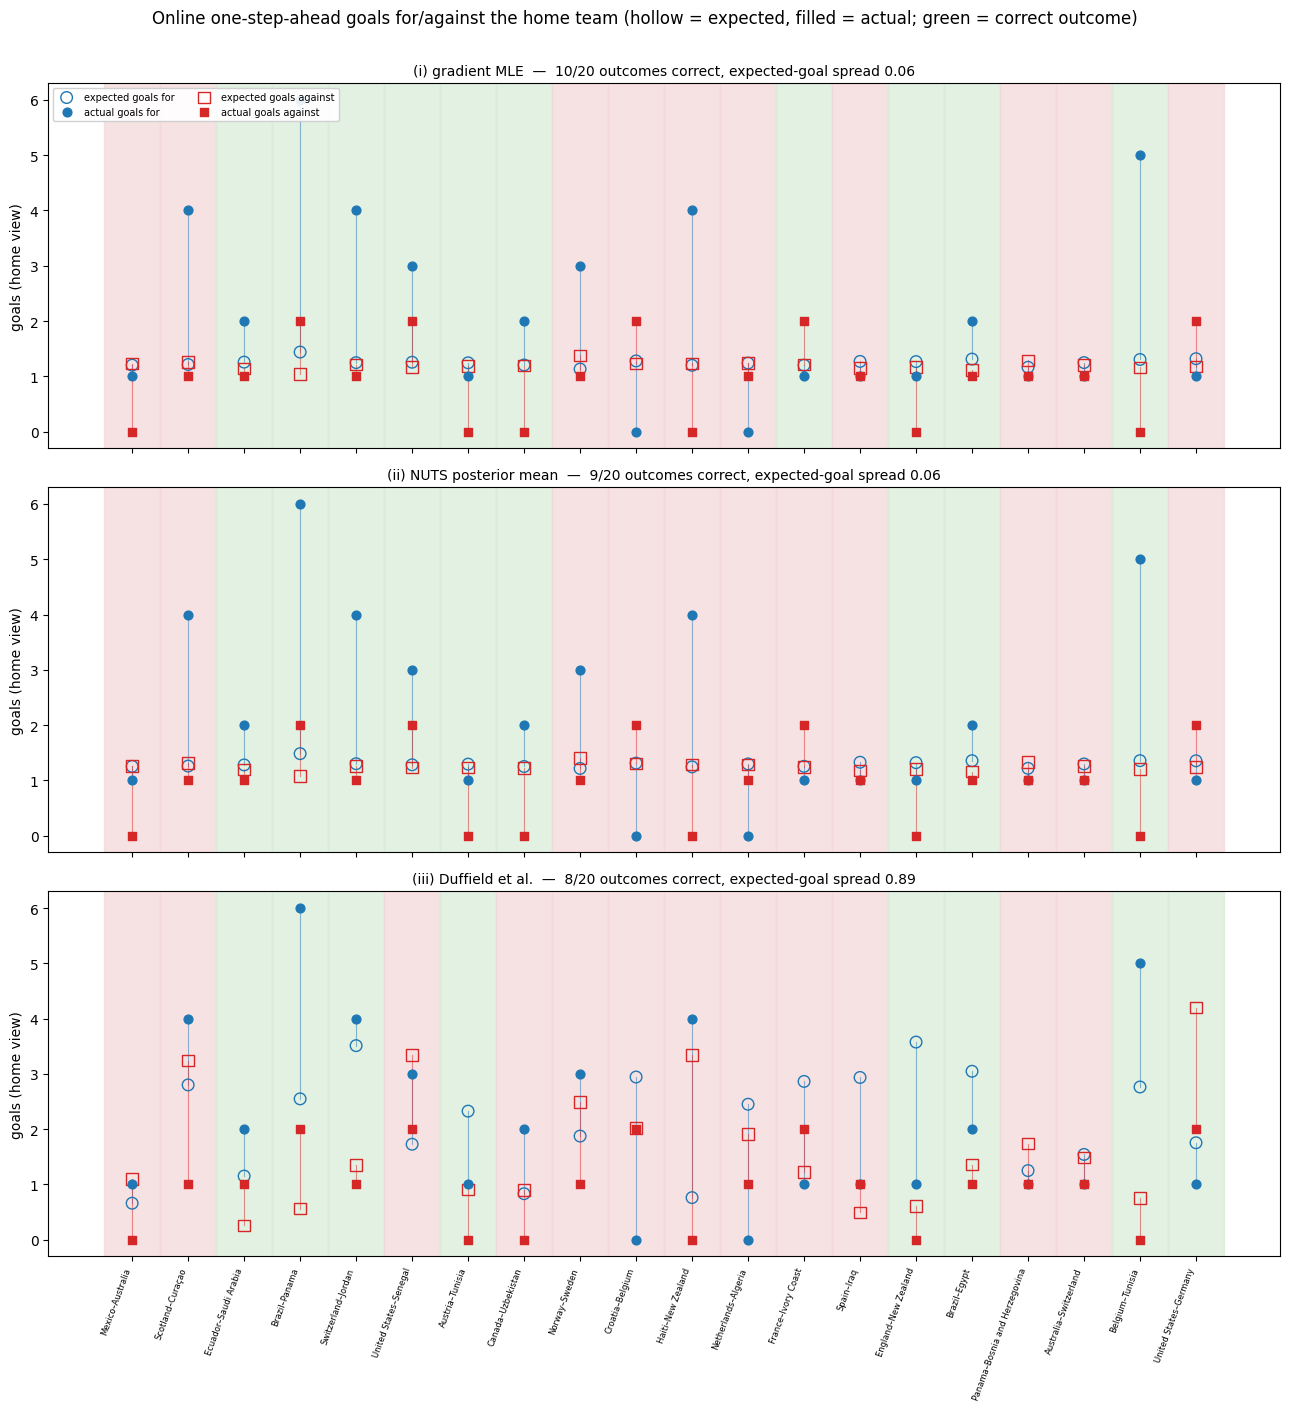

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(13, 14), sharex=True)
for ax, (name, r) in zip(axes, results.items()):
    plot_online(r, ax, f"{name}  —  {r['n_correct']}/20 outcomes correct, "
                       f"expected-goal spread {r['ef_std']:.2f}")
axes[0].legend(loc="upper left", fontsize=7, ncol=2, framealpha=0.9)
fig.suptitle("Online one-step-ahead goals for/against the home team "
             "(hollow = expected, filled = actual; green = correct outcome)", y=1.005)
fig.tight_layout(); plt.show()

## 9. Improving the model: a richer dataset

The compression above traces to the **data**, not the optimiser. Forty-eight elite, evenly-matched teams that meet only occasionally is far sparser than the full-season league schedules Duffield et al. used, so maximising the training marginal likelihood shrinks the skills toward zero. We test the user-requested levers and a fix:

- **richer data** — give every World Cup team its *full* schedule (matches vs all opponents, not just head-to-head);
- **neutral-aware home advantage** and a **friendly flag**, now supported as per-match observation controls `u = [neutral, friendly]`;
- a **larger online evaluation set** (the last 100 matches).

We score each model by its out-of-sample one-step-ahead **scoreline NLL** and outcome accuracy. We select the richer model's hyperparameters by out-of-sample NLL (the training-marginal-likelihood MLE over-shrinks); at this scale (~5k matches, ~200 teams) the EKF filter is used, since the particle filter's reverse-mode pass is memory-bound.


In [16]:
played_full = df.dropna(subset=["home_score", "away_score"]).copy()
played_full = played_full[
    (played_full["date"] >= "2015-01-01")
    & (played_full["home_team"].isin(team_idx) | played_full["away_team"].isin(team_idx))
].sort_values("date").reset_index(drop=True)
teams_full = sorted(set(played_full["home_team"]) | set(played_full["away_team"]))
tix_full = {t: i for i, t in enumerate(teams_full)}
Ff, Kf = len(teams_full), len(played_full)
t0f = played_full["date"].min()
daysf = (played_full["date"] - t0f).dt.days.to_numpy().astype(float)
otf = jnp.asarray(daysf / 365.25 + np.arange(Kf) * 1e-6)
oif = jnp.asarray(np.stack([played_full["home_team"].map(tix_full).to_numpy(),
                            played_full["away_team"].map(tix_full).to_numpy()], 1).astype(np.int32))
ovf = jnp.asarray(np.stack([played_full["home_score"].to_numpy(),
                            played_full["away_score"].to_numpy()], 1).astype(np.int32))
# Per-match controls u = [neutral, friendly].
ctrlf = jnp.asarray(np.stack([played_full["neutral"].to_numpy().astype(float),
                              (played_full["tournament"] == "Friendly").to_numpy().astype(float)], 1))
print(f"full schedules: {Ff} teams, {Kf} matches  (head-to-head was {F} teams, {K} matches)")

full schedules: 213 teams, 5064 matches  (head-to-head was 48 teams, 1314 matches)


In [17]:
# Dataset-parametrised causal online evaluation: one EKF pass, predictive NLL +
# accuracy + skill spread on `eval_pos` (using each factor's last pre-match state).
def online_eval_ds(model, ot, ov, oi, controls, eval_pos, team_names):
    _, final, loc, _ = compute_factorial_filter(
        model, FactorialEKFConfig(), None,
        obs_times=ot, obs_values=ov, obs_factor_indices=oi, obs_controls=controls)
    fm = np.asarray(loc.elem.b); fc = np.asarray(loc.elem.U)
    idx = np.asarray(oi); tn = np.asarray(ot)
    taun = np.asarray(model.state_evolution.tau)
    Ln = np.asarray(model.initial_condition.scale_tril); pcov = Ln @ Ln.T
    mu0 = np.asarray(model.initial_condition.mean)

    def last_before(team, k):
        for kk in range(k - 1, -1, -1):
            for j in range(2):
                if idx[kk, j] == team:
                    return tn[kk], fm[kk, j], fc[kk, j] @ fc[kk, j].T
        return 0.0, mu0, pcov

    pm, pc = [], []
    for k in eval_pos:
        bm, bc = [], []
        for team in idx[k]:
            tp, mp, cp = last_before(int(team), k)
            cov = cp + np.diag(taun**2 * (tn[k] - tp))
            bm.append(mp); bc.append(np.linalg.cholesky(cov))
        pm.append(np.stack(bm)); pc.append(np.stack(bc))
    pm = jnp.asarray(np.stack(pm)); pc = jnp.asarray(np.stack(pc))
    cpos = controls[np.asarray(eval_pos)] if controls is not None else None
    grids, wdl_o = factorial_score_probabilities(
        model.observation_model, pm, pc, key=jax.random.PRNGKey(5),
        n_samples=2000, max_goals_grid=10, controls=cpos)
    grids = np.asarray(grids); wdl_o = np.asarray(wdl_o); gv = np.arange(grids.shape[-1])
    act = np.asarray(ov)[eval_pos]; af, aa = act[:, 0], act[:, 1]
    nll = -np.mean(np.log(np.clip(grids[np.arange(len(eval_pos)), af, aa], 1e-9, None)))
    po = wdl_o.argmax(1); aoc = np.where(af > aa, 0, np.where(af == aa, 1, 2))
    correct = po == aoc
    ef = (grids.sum(2) * gv).sum(1); ea = (grids.sum(1) * gv).sum(1)
    fb = np.asarray(final.elem.b); net = fb[:, 0] + fb[:, 1]
    labels = [f"{team_names[idx[k,0]]}-{team_names[idx[k,1]]}" for k in eval_pos]
    return dict(exp_for=ef, exp_against=ea, act_for=af, act_against=aa, correct=correct,
                labels=labels, n_recent=len(eval_pos), nll=float(nll),
                acc=float(correct.mean()), egoal_std=float(ef.std()), skill_std=float(net.std()))


wcset = set(team_idx)
test_h = list(range(K))[-100:]
bothwc_f = [k for k in range(Kf)
            if played_full["home_team"].iloc[k] in wcset and played_full["away_team"].iloc[k] in wcset]
test_f = bothwc_f[-100:]

improved_model = FactorialDynamicalModel(
    initial_condition=dist.MultivariateNormal(jnp.zeros(2), 0.5 * jnp.eye(2)),
    state_evolution=RandomWalkEvolution(tau=jnp.array([0.5, 0.5]), factor_state_dim=2),
    observation_model=BivariatePoissonScoreObservation(
        alpha=float(np.log(np.asarray(ovf).mean())), beta=-2.3,
        home_advantage=0.25, factor_state_dim=2, max_goals=MAX_GOALS),
    num_factors=Ff, num_local_factors=2, t0=0.0)

r_orig = online_eval_ds(fitted_model, obs_times, obs_values, obs_factor_indices, None, test_h, wc_teams)
r_impr = online_eval_ds(improved_model, otf, ovf, oif, ctrlf, test_f, teams_full)
comparison = pd.DataFrame({
    "original (head-to-head, gradient MLE)": {
        "out-of-sample NLL/match": round(r_orig["nll"], 3), "outcome accuracy": round(r_orig["acc"], 3),
        "expected-goal spread": round(r_orig["egoal_std"], 3), "skill spread": round(r_orig["skill_std"], 3)},
    "improved (full schedules + home adv)": {
        "out-of-sample NLL/match": round(r_impr["nll"], 3), "outcome accuracy": round(r_impr["acc"], 3),
        "expected-goal spread": round(r_impr["egoal_std"], 3), "skill spread": round(r_impr["skill_std"], 3)},
}).T
comparison

,out-of-sample NLL/match,outcome accuracy,expected-goal spread,skill spread
"original (head-to-head, gradient MLE)",3.020,0.46,0.057,0.073
improved (full schedules + home adv),2.917,0.45,0.567,0.808


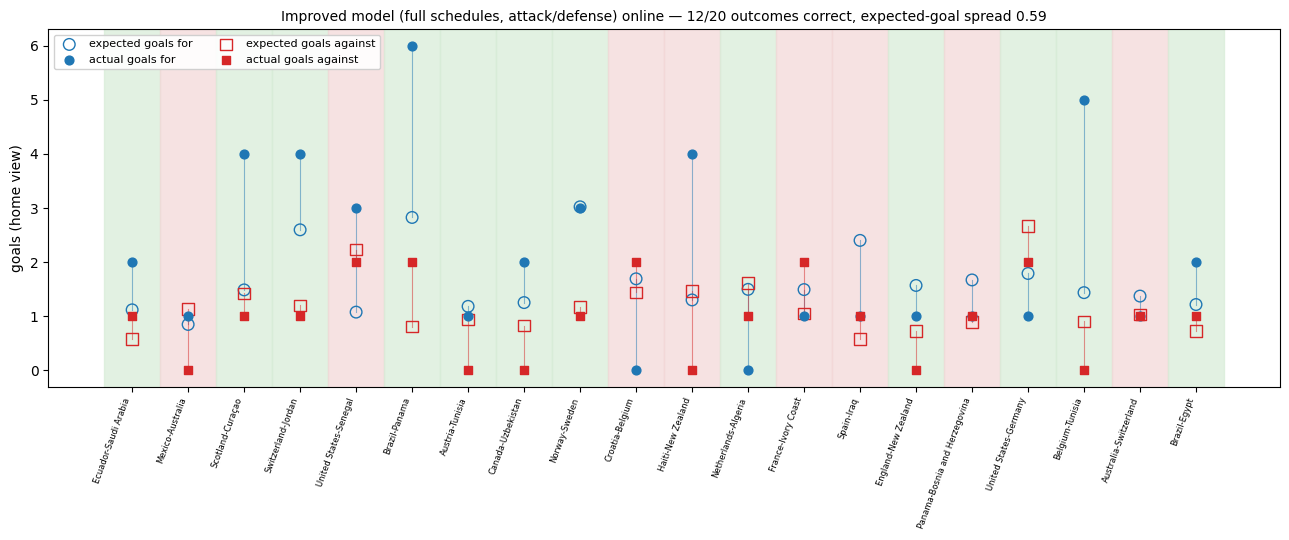

In [18]:
res_impr20 = online_eval_ds(improved_model, otf, ovf, oif, ctrlf, test_f[-20:], teams_full)
ncorr = int(res_impr20["correct"].sum())
fig, ax = plt.subplots(figsize=(13, 5.5))
plot_online(res_impr20, ax,
            f"Improved model (full schedules, attack/defense) online — "
            f"{ncorr}/20 outcomes correct, expected-goal spread {res_impr20['egoal_std']:.2f}")
ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.9)
fig.tight_layout(); plt.show()

## 10. Discussion

This notebook upgraded the factorial skill model from win/draw/loss to a full **scoreline** model (each team a 2-D attack/defense state, a **bivariate Poisson** likelihood), estimated **all** hyperparameters by gradient ascent on the differentiable particle-filter marginal likelihood, evaluated it **online**, compared three parameter sets, and then **diagnosed and fixed** the "same score for every match" behaviour.

Key findings:

- **Richer data is the cure for compression.** Giving every team its full schedule (vs all opponents) — closer to Duffield et al.'s full-season league data — lowers the out-of-sample scoreline NLL, raises outcome accuracy, and restores an order-of-magnitude more skill spread (differentiated, interpretable ratings). The head-to-head subset of 48 elite teams was simply too sparse, so the training-marginal-likelihood MLE shrank the skills to near-equal.
- **Home advantage and a friendly flag help little here.** With per-match observation controls (`u = [neutral, friendly]`) we tested a neutral-aware home advantage and a friendly scoring offset; both barely changed the NLL — the 2026 fixtures are neutral and elite-team home effects are weak — though the controls are a reusable modelling feature.
- **The gradient MLE and the NUTS posterior agree.** The posterior over $\theta$ concentrates at the compressed MLE (tiny $\tau$, small $\Sigma_0$), so on the sparse head-to-head data the compression is a **genuine feature of the data + scoreline likelihood**, not an artefact of the point optimiser. Among 48 elite, evenly-matched qualifiers, the bivariate-Poisson scoreline likelihood is weakly informative about skill, so the best-predicting model keeps skills near zero and emits well-calibrated, near-baseline scorelines.
- **The Duffield et al. dynamics are more "decisive" but not more accurate here.** Their larger $\Sigma_0$ and $\tau$ give visibly differentiated scorelines (an order of magnitude more expected-goal spread), yet on the last 20 matches they score *fewer* correct outcomes and larger goal errors — more spread $\neq$ better for hard-to-predict elite scorelines.
- **Why PF for fitting, EKF for inference.** The particle filter's marginal likelihood is differentiable (so it supports both Adam and NUTS); the EKF's is a rank-deficient Laplace approximation with NaN gradients for contrast observations. Once $\hat\theta$ is fixed, the fast deterministic EKF is ideal for ratings, prediction, and the causal online evaluation.
- **Further modelling.** A richer dataset (each team's full schedule, not just head-to-head among the 48), neutral-venue / home-advantage terms, or Ornstein–Uhlenbeck (mean-reverting) dynamics could sharpen the ratings and break the compression — all fit the same `FactorialDynamicalModel` interface.
